In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from scipy.stats import chi2_contingency
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import re
import string
import seaborn as sns

import math
from scipy.stats import ttest_ind

In [67]:
def contains_unicode_char(s):
    for char in s:
        if ord(char) > 127:
            return True
    return False

In [68]:
import os

for filename in os.listdir('../Dataset/'):
    print(filename)

british-english-sms-corpora.doc
ENRON Spam Dataset
ExAIS_SMS Spam Dataset
KOR_smishing_data_raw
Mendeley_Dataset_5971.csv
Singapore_smsCorpus_en_2015.03.09_all.json
smishtank.csv
sp24-smishing
SPAM-Hunter_full_dataset_messages.csv
super_sms_dataset.csv
tld-list-basic.csv
UCI_SMSSpamCollection


In [69]:
# #these two dataset are the same
# moz_smishing_data = pd.read_csv("../Dataset/MOZ-SMS.csv", encoding='utf-8')
# moz_smishing_data.head()

In [70]:
# moz_smishing_data['label'].value_counts()

In [71]:
# non_port_entries = 0
# for i in moz_smishing_data['text']:
#     if not contains_unicode_char(i):
#         print(i)
#         non_port_entries += 1

# non_port_entries

In [72]:
# ban_barta = pd.read_csv("../Dataset/BangalaBarta.csv", encoding='utf-8')
# ban_barta.head()

In [73]:
# print(len(ban_barta))

In [74]:
# ban_barta['label'].value_counts()

In [75]:
# non_ban_entries = 0
# for i in ban_barta['text']:
#     if not contains_unicode_char(i):
#         print(i)
#         non_ban_entries += 1

# non_ban_entries

In [76]:
# ban_spam = pd.read_csv("../Dataset/bangla_spam.csv", encoding='utf-8')
# ban_spam = ban_spam.dropna(axis=1)

# ban_spam.head()

In [77]:
# ban_spam['type'].value_counts()

In [78]:
# non_ban_entries = 0
# for i in ban_spam['text']:
#     if not contains_unicode_char(i):
#         print(i)
#         non_ban_entries += 1

# non_ban_entries

In [79]:
# rev_india = pd.read_excel("../Dataset/revisedindiandataset.xls", engine='xlrd')
# rev_india.head()

In [80]:
# rev_india['label'].value_counts()

In [81]:
# non_ind_entries = 0
# for i in rev_india['msg']:
#     if not contains_unicode_char(i):
#         print(i)
#         non_ind_entries += 1

# non_ind_entries

In [82]:
# kor_smishing = pd.read_csv("../Dataset/KOR_smishing_data_raw/KOR_phishing_data_raw.csv", encoding='utf-8')

# kor_smishing.head()

In [83]:
# non_kor_entries = 0
# for i in kor_smishing['content']:
#     if not contains_unicode_char(i):
#         print(i)
#         non_kor_entries += 1

# non_kor_entries

In [84]:
# kor_smishing['class'].value_counts()

In [85]:
def read_file(file_path):
    with open(file_path, 'r') as file:
        content = file.readlines()
    return content

In [86]:
enron_dataset = {'ham':[], 'spam':[]}
for i in range(6):
    directory_ham = "../Dataset/ENRON Spam Dataset/enron"+str(i+1)+"/ham"
    directory_spam = "../Dataset/ENRON Spam Dataset/enron"+str(i+1)+"/spam"

    # Loop through all files in the directory_ham
    for filename in os.listdir(directory_ham):
        # Check if it's a file (not a directory_ham)
        if os.path.isfile(os.path.join(directory_ham, filename)):
            # Open the file and do something with it
            with open(os.path.join(directory_ham, filename), 'r', encoding='utf-8', errors='ignore') as file:
                content = file.read()
                # print(content)
                # print(''.join(content.split('\n')[1:]))
                enron_dataset['ham'].append(''.join(content.split('\n')[1:]))
                # Process the content of the file here
                # print(content)
                # break
    
    # Loop through all files in the directory_spam
    for filename in os.listdir(directory_spam):
        # Check if it's a file (not a directory_spam)
        if os.path.isfile(os.path.join(directory_spam, filename)):
            # Open the file and do something with it
            with open(os.path.join(directory_spam, filename), 'r', encoding='utf-8', errors='ignore') as file:
                content = file.read()
                # print(content)
                # print(''.join(content.split('\n')[1:]))
                enron_dataset['spam'].append(''.join(content.split('\n')[1:]))
                # Process the content of the file here
                # print(content)
                # break

print(len(enron_dataset['ham']))
print(len(enron_dataset['spam']))

16545
17170


In [87]:
enron_dataset['ham']

['',
 'gary , production from the high island larger block a - 1 # 2 commenced onsaturday at 2 : 00 p . m . at about 6 , 500 gross . carlos expects between 9 , 500 and10 , 000 gross for tomorrow . vastar owns 68 % of the gross production .george x 3 - 6992- - - - - - - - - - - - - - - - - - - - - - forwarded by george weissman / hou / ect on 12 / 13 / 99 10 : 16am - - - - - - - - - - - - - - - - - - - - - - - - - - -daren j farmer12 / 10 / 99 10 : 38 amto : carlos j rodriguez / hou / ect @ ectcc : george weissman / hou / ect @ ect , melissa graves / hou / ect @ ectsubject : vastar resources , inc .carlos ,please call linda and get everything set up .i \' m going to estimate 4 , 500 coming up tomorrow , with a 2 , 000 increase eachfollowing day based on my conversations with bill fischer at bmar .d .- - - - - - - - - - - - - - - - - - - - - - forwarded by daren j farmer / hou / ect on 12 / 10 / 99 10 : 34am - - - - - - - - - - - - - - - - - - - - - - - - - - -enron north america corp .f

In [88]:
# british_dataset = read_file("../Dataset/british_english_sms_corpus.txt")
# # for i in british_dataset:
# #     print(i)
# # british_dataset.index('SMS Ham\n')
# # british_dataset.index('SMS Spam\n')
# british_ham = [i[:-1] for i in british_dataset[17:480] if i!='\n']
# british_spam = [i[:-1] for i in british_dataset[482:] if i!='\n']

In [89]:
# british_ham

In [90]:
# british_spam

In [91]:
# print(len(british_ham))
# print(len(british_spam))

In [92]:
with open('../Dataset/Singapore_smsCorpus_en_2015.03.09_all.json', 'r') as file:
        singapore_dataset = json.load(file)

In [93]:
singapore_dataset_all_mesages = []
for i in singapore_dataset['smsCorpus']['message']:
    # print(type(i['text']['$']))
    singapore_dataset_all_mesages.append(i['text']['$'])

In [94]:
singapore_dataset_all_mesages

['Bugis oso near wat...',
 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
 'I dunno until when... Lets go learn pilates...',
 'Den only weekdays got special price... Haiz... Cant eat liao... Cut nails oso muz wait until i finish drivin wat, lunch still muz eat wat...',
 'Meet after lunch la...',
 'm walking in citylink now ü faster come down... Me very hungry...',
 '5 nights...We nt staying at port step liao...Too ex',
 'Hey pple...$700 or $900 for 5 nights...Excellent location wif breakfast hamper!!!',
 'Yun ah.the ubi one say if ü wan call by tomorrow.call 67441233 look for irene.ere only got bus8,22,65,61,66,382. Ubi cres,ubi tech park.6ph for 1st 5wkg days.èn',
 'Hey tmr maybe can meet you at yck',
 'Oh...i asked for fun. Haha...take care. ü',
 'We are supposed to meet to discuss abt our trip... Thought xuhui told you? In the afternoon. Thought we can go for lesson after that',
 't finish my film yet...',
 'm havin

In [95]:
UCI_dataset = read_file('../Dataset/UCI_SMSSpamCollection')

In [96]:
UCI_dataset = [i[:-1] for i in UCI_dataset]

In [97]:
UCI_dataset_ham, UCI_dataset_spam = [], []
for i in UCI_dataset:
    if i[0]=='h':
        UCI_dataset_ham.append(i[4:])
    else:
        UCI_dataset_spam.append(i[5:])

In [98]:
UCI_dataset_ham

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
 'Ok lar... Joking wif u oni...',
 'U dun say so early hor... U c already then say...',
 "Nah I don't think he goes to usf, he lives around here though",
 'Even my brother is not like to speak with me. They treat me like aids patent.',
 "As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune",
 "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.",
 "I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.",
 'I HAVE A DATE ON SUNDAY WITH WILL!!',
 "Oh k...i'm watching here:)",
 'Eh u remember how 2 spell his name... Yes i did. He v naughty make until i v wet.',
 'Fine if t

In [99]:
UCI_dataset_spam

["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
 "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv",
 'WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.',
 'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030',
 'SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info',
 'URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18',
 'XXXMobileMovieClub: To use your credit, click the WAP link in th

In [100]:
print(len(UCI_dataset_ham))
print(len(UCI_dataset_spam))

4827
747


In [101]:
UCI_csv = pd.DataFrame()
label, message = [], []
for i in UCI_dataset:
    xx = i.split('\t')
    # print(len(xx),xx)
    label.append(xx[0])
    message.append(xx[1])

UCI_csv['Message'] = message
UCI_csv['Label'] = label

# UCI_csv.to_csv('../Dataset/UCI_Smishing_Dataset.csv', index=None)
UCI_csv.head()

,Message,Label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [102]:
mendeley_dataset = pd.read_csv('../Dataset/Mendeley_dataset_5971.csv')
mendeley_dataset.head()

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No


In [103]:
mendeley_dataset['LABEL'].value_counts()

LABEL
ham         4844
Smishing     616
spam         466
Spam          23
smishing      22
Name: count, dtype: int64

In [104]:
#full intersection
len(set(UCI_csv['Message']).intersection(set(mendeley_dataset['TEXT'])))

4753

In [105]:
#ham intersection
len(set(UCI_csv[UCI_csv['Label']=='ham']['Message']).intersection(set(mendeley_dataset['TEXT'])))

4199

In [106]:
#spam intersection
len(set(UCI_csv[UCI_csv['Label']=='spam']['Message']).intersection(set(mendeley_dataset['TEXT'])))

554

In [107]:
smishtank_dataset = pd.read_csv('../Dataset/smishtank.csv', encoding='unicode_escape')

In [108]:
smishtank_dataset.head()

,messageid,Fulltext,Sender,SenderType,timeReceived,MainText,Url,Subdomain,Domain,TLD,...,Phishing,Suspicious,Malware,Brand,URL Subcategory,Message Categories,FullyQualifiedDomain,Domain Registrar,Domain Creation Date,Domain Last Update
0,3,"Text Message\nThu, Jul 29, 19:10\nCostco: Dani...",42003,Short Code,"03/31/2022, 21:58:50","Costco: Daniel, the code 42003 printed on your...",f2gpy.info/RzNKEwsZve,NaN,f2gpy,info,...,0,0,0,Costco,Random Domain,Prize/Contest,f2gpy.info,"NameCheap, Inc.",7/28/2021,7/31/2021
1,5,"<\n+1 (872) 279-0672 >\nText Message\nWed, Feb...",+1 (872) 279-0672,Phone Number,"04/02/2022, 02:59:56","Hi, you still owe UPS $4.10 USD in customs fee...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,UPS,NaN,Delivery,NaN,NaN,NaN,NaN
2,6,"<\n+1 (806) 224-7886 >\nText Message\nThu, Sep...",+1 (806) 224-7886,Phone Number,"04/02/2022, 03:03:00",wel01.us/r/rest05 WELLS FARGO(CS):Profile lock...,wel01.us/r/rest05,NaN,wel01,us,...,0,0,0,WELLS FARGO,Random Domain,Account Alert,wel01.us,"NameCheap, Inc.",8/30/2021,8/30/2021
3,7,Text Message\nToday 2:30 PM\nwho played golf\n...,NaN,NaN,"04/02/2022, 23:42:38","Hi, are you who played golf together last time...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Wrong Number/Romance Scam,NaN,NaN,NaN,NaN
4,8,(8\n+1 (775) 537-4497\ncanador to them\nTato m...,+1 (775) 537-4497,Phone Number,"04/02/2022, 23:46:34","(8 Hi Julianne long time no see, I'm Aleen, ho...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Wrong Number/Romance Scam,NaN,NaN,NaN,NaN


In [109]:
smishtank_dataset['MainText']

0       Costco: Daniel, the code 42003 printed on your...
1       Hi, you still owe UPS $4.10 USD in customs fee...
2       wel01.us/r/rest05 WELLS FARGO(CS):Profile lock...
3       Hi, are you who played golf together last time...
4       (8 Hi Julianne long time no see, I'm Aleen, ho...
                              ...                        
1086    IRS_TAX_RE-FUND_ID_#01Q F20J091.pdf PDF Docume...
1087                 Hey. Amy when are you picking me up?
1088    Hello dear user Your package has arrived at th...
1089    Hey, it's John here, I'm having a hard time de...
1090    Its Jim! Im trying to deliver your parcel. Ple...
Name: MainText, Length: 1091, dtype: object

In [110]:
sp24_dataset = pd.read_csv('../Dataset/sp24-smishing/phishing_messages.csv', encoding='unicode_escape')
# sp24_dataset = pd.read_csv('../Dataset/sp24-smishing/phishing_campaigns.csv', encoding='unicode_escape')
sp24_dataset = sp24_dataset.dropna()
len(sp24_dataset)

68029

In [111]:
sp24_dataset['message']

0        Join today and enjoy 400% casino bonus, START ...
1        Einzigartiges Angebot- 200% bis zu 100 EUR +50...
2        An up to Â£3 FREEBIE has been dropped onto you...
3        We just missed you today! Schedule a redeliver...
4        In order to avoid any loss to you, please corr...
                               ...                        
68024    New RHRY L0gin ã www.bitoii.com ã Username...
68025    New RHRY L0gin ã www.bitoii.com ã Username...
68026    sms180217@2-tdbanking.sms.com / Zelle Detected...
68027    sms370017@2-tdbanking.sms.com / Zelle Detected...
68028    \r\nChronopost : Votre colis est en attente d'...
Name: message, Length: 68029, dtype: object

In [112]:
ExAIS_dataset = pd.read_csv('../Dataset/ExAIS_SMS Spam Dataset/all_ExAIS_SPAM_Dataset.csv', na_values=["null", "NaN"], keep_default_na=True).fillna("")
ExAIS_dataset.head()

,SMS,Occasion,Target1,Target2,Date,Unknown,Label,Message,Unnamed: 8,Unnamed: 9,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,SMS,send,127,127,4/9/2014 8:29,1026,SPAM,CANCLE,,,...,,,,,,,,,,
1,SMS,receive,127,127,4/9/2014 8:25,1026,SPAM,Your plan Smallie.is going to be renewed. Plea...,,,...,,,,,,,,,,
2,SMS,receive,127,127,4/9/2014 8:25,1026,SPAM,Dear Glo subscriber,you just passed 80% of your Plan Validity Per...,,...,,,,,,,,,,
3,SMS,receive,127,127,1/9/2014 14:25,1026,SPAM,Welcome to Smallie. It will expire on 04/09/20...,,,...,,,,,,,,,,
4,SMS,send,127,127,25/08/2014 10:13,1026,SPAM,Info,,,...,,,,,,,,,,


In [113]:
ExAIS_dataset.iloc[:, 7] = ExAIS_dataset.iloc[:, 7:].astype(str).agg(" ".join, axis=1)

ExAIS_dataset = ExAIS_dataset.iloc[:, :8]

# ExAIS_dataset.to_csv('../Dataset/ExAIS_SMS Spam Dataset/cleaned_all_ExAIS_SPAM_Dataset.csv')

ExAIS_dataset.head(10)

,SMS,Occasion,Target1,Target2,Date,Unknown,Label,Message
0,SMS,send,127,127,4/9/2014 8:29,1026,SPAM,CANCLE
1,SMS,receive,127,127,4/9/2014 8:25,1026,SPAM,Your plan Smallie.is going to be renewed. Plea...
2,SMS,receive,127,127,4/9/2014 8:25,1026,SPAM,Dear Glo subscriber you just passed 80% of yo...
3,SMS,receive,127,127,1/9/2014 14:25,1026,SPAM,Welcome to Smallie. It will expire on 04/09/20...
4,SMS,send,127,127,25/08/2014 10:13,1026,SPAM,Info
5,SMS,send,127,127,25/08/2014 07:47,1026,SPAM,1
6,SMS,receive,127,127,25/08/2014 07:38,1026,SPAM,Please send :1 for Day Plans2 for Week Plans...
7,SMS,send,127,127,25/08/2014 07:38,1026,SPAM,ACTIVATE
8,SMS,receive,127,127,25/08/2014 07:37,1026,SPAM,Please send ACTIVATE to 127 for a list of opti...
9,SMS,send,127,127,25/08/2014 07:37,1026,SPAM,PAYYOU


In [114]:
ExAIS_dataset['Label'].value_counts()

Label
HAM     2890
SPAM    2350
Name: count, dtype: int64

In [115]:
spamhunter_dataset = pd.read_csv('../Dataset/SPAM-Hunter_full_dataset_messages.csv', delimiter='abcdexyagh')
spamhunter_dataset.head()

C:\Users\mmia43\AppData\Local\Temp\ipykernel_23380\246060161.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  spamhunter_dataset = pd.read_csv('../Dataset/SPAM-Hunter_full_dataset_messages.csv', delimiter='abcdexyagh')


,Messages
0,CASH BUY AND HOLD XXXXX SHARES OF ALPSMOTOR XX...
1,Last X hr Left to Activate your Godaddy XX Off...
2,Pongal Gift 1.Opkt be bill on your card on 11....
3,NSE BSE CASH PREMIUM BUY `` MOHITIND `` 58.75 ...
4,XX SPINS be wait for you when you SignUp at Lu...


In [116]:
print(len(spamhunter_dataset))
print(len(set(spamhunter_dataset['Messages'])))

25826
25295


In [117]:
super_dataset = pd.read_csv('../Dataset/super_sms_dataset.csv', encoding='mac_roman')
super_dataset.head()

,SMSes,Labels
0,There be an update for your delivery CC 017281...,1.0
1,watch your favorite english movies of all genr...,1.0
2,aur what is the status for fms,0.0
3,hi shalini sundi thank you for dialling speci...,1.0
4,m tryin to understand too...,0.0


In [118]:
super_dataset['Labels'].value_counts()

Labels
0.0    40830
1.0    26178
Name: count, dtype: int64

In [119]:
def deep_clean(text_list):
    cleaned = []
    for text in text_list:
        # 1. Remove URLs (as we discussed before)
        text = re.sub(r'https?://\S+|www\.\S+', '', str(text))
        
        # 2. Remove any word that contains a number
        # \S*\d\S* matches any non-whitespace string containing at least one digit
        text = re.sub(r'\S*\d\S*', '', text)
        
        # 3. Remove punctuation and extra whitespace
        text = re.sub(r'[^\w\s]', '', text)
        cleaned.append(text.strip())
    return cleaned

In [120]:

def get_chi2_drift_scores(texts_2011, texts_2024, max_features=500):
    """
    Calculates Chi-square scores for words comparing two datasets.
    """
    # 1. Vectorize (Binary=True focuses on presence/absence in messages)
    vec = CountVectorizer(stop_words='english', max_features=max_features, binary=True)
    
    all_texts = texts_2011 + texts_2024
    X = vec.fit_transform(all_texts).toarray()
    words = vec.get_feature_names_out()
    
    n_11 = len(texts_2011)
    n_24 = len(texts_2024)
    
    counts_11 = X[:n_11].sum(axis=0)
    counts_24 = X[n_11:].sum(axis=0)
    
    drift_data = []
    for i, word in enumerate(words):
        # Contingency Table: [[Word in 2011, Word in 2024], [No word in 2011, No word in 2024]]
        observed = np.array([
            [counts_11[i], counts_24[i]],
            [n_11 - counts_11[i], n_24 - counts_24[i]]
        ])
        
        # Calculate Chi-square
        chi2, p, _, _ = chi2_contingency(observed, correction=True)
        
        # Determine Direction
        rate_11 = counts_11[i] / n_11
        rate_24 = counts_24[i] / n_24
        direction = '2024' if rate_24 > rate_11 else '2011'
        
        drift_data.append({'word': word, 'chi2': chi2, 'p': p, 'direction': direction})
    
    return pd.DataFrame(drift_data)

In [121]:
def print_top_top_k_drift(df, top_k=20):
    """
    Separates the drift results into two groups (2011 and 2024)
    and prints the top top_k most significant words for each.
    """
    # Filter for statistically significant words only
    significant_df = df[df['p'] < 0.05]

    print(f"Total significant words found: {len(significant_df)}")

    # Group 1: Characteristic of 2011 (Old)
    top_2011 = significant_df[significant_df['direction'] == '2011'].sort_values(by='chi2', ascending=False).head(top_k)

    # Group 2: Characteristic of 2024 (New)
    top_2024 = significant_df[significant_df['direction'] == '2024'].sort_values(by='chi2', ascending=False).head(top_k)

    print("2011 datasets")
    print(set(top_2011['word']))
    # print(top_2011[['word', 'chi2']].to_string(index=False))
    
    print("\n" + "="*50 + "\n")
    
    print("2024 datasets")
    print(set(top_2024['word']))
    # print(top_2024[['word', 'chi2']].to_string(index=False))


In [127]:
def generate_drift_wordcloud(df, output_file="concept_drift_cloud.png"):
    # Filter for significant drift (p < 0.05)
    significant_df = df[df['p'] < 0.05]
    
    # Create a dictionary of {word: chi2_score}
    weights = dict(zip(significant_df['word'], significant_df['chi2']))
    
    # Custom color function: Blue for 2011, Red for 2024
    def color_func(word, **kwargs):
        direction = significant_df[significant_df['word'] == word]['direction'].values[0]
        return "rgb(200, 50, 50)" if direction == '2024' else "rgb(50, 50, 200)"

    wc = WordCloud(
        width=1600, height=800,
        background_color='white',
        relative_scaling=0.5,
        prefer_horizontal=0.9
    ).generate_from_frequencies(weights)

    plt.figure(figsize=(20, 10))
    recolored_wc = wc.recolor(color_func=color_func)

    # MANUALLY convert to array to avoid the WordCloud internal bug
    wc_array = np.array(recolored_wc.to_image())

    plt.figure(figsize=(20, 10))
    plt.imshow(wc_array, interpolation='bilinear') # Pass the array, not the WC object
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(output_file, dpi=300)
    plt.show()

In [123]:
def clean_links(text):
    """
    Removes or replaces URLs from a string.
    """
    # This regex catches: http, https, www, and common TLD patterns
    url_pattern = r'https?://\S+|www\.\S+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,4}/\S*'
    
    clean_text = re.sub(url_pattern, '', text)
    
    # Remove extra whitespace left behind
    clean_text = ' '.join(clean_text.split())
    
    return clean_text

In [124]:
texts_2011 = [clean_links(UCI_dataset_spam[i]) for i in range(len(UCI_dataset_spam))]
texts_2011 = deep_clean(texts_2011)

texts_2024 = [clean_links(str(t)) for t in smishtank_dataset['MainText'] if pd.notnull(t) and str(t).strip() != ""]
texts_2024 = deep_clean(texts_2024)

In [125]:
df_results = get_chi2_drift_scores(texts_2011, texts_2024)
print_top_top_k_drift(df_results, top_k=25)

Total significant words found: 374
2011 datasets
{'awarded', 'send', 'mins', 'win', 'just', 'won', 'txt', 'free', 'text', 'draw', 'ur', 'urgent', 'mobile', 'tone', 'claim', 'cash', 'nokia', 'holiday', 'po', 'tcs', 'landline', 'box', 'guaranteed', 'prize', 'line'}


2024 datasets
{'provide', 'warehouse', 'incomplete', 'address', 'avoid', 'payment', 'tax', 'personal', 'delivered', 'click', 'irs', 'refund', 'usps', 'open', 'browser', 'safari', 'copy', 'confirm', 'package', 'information', 'arrived', 'exit', 'process', 'link', 'account'}


<Figure size 2000x1000 with 0 Axes>

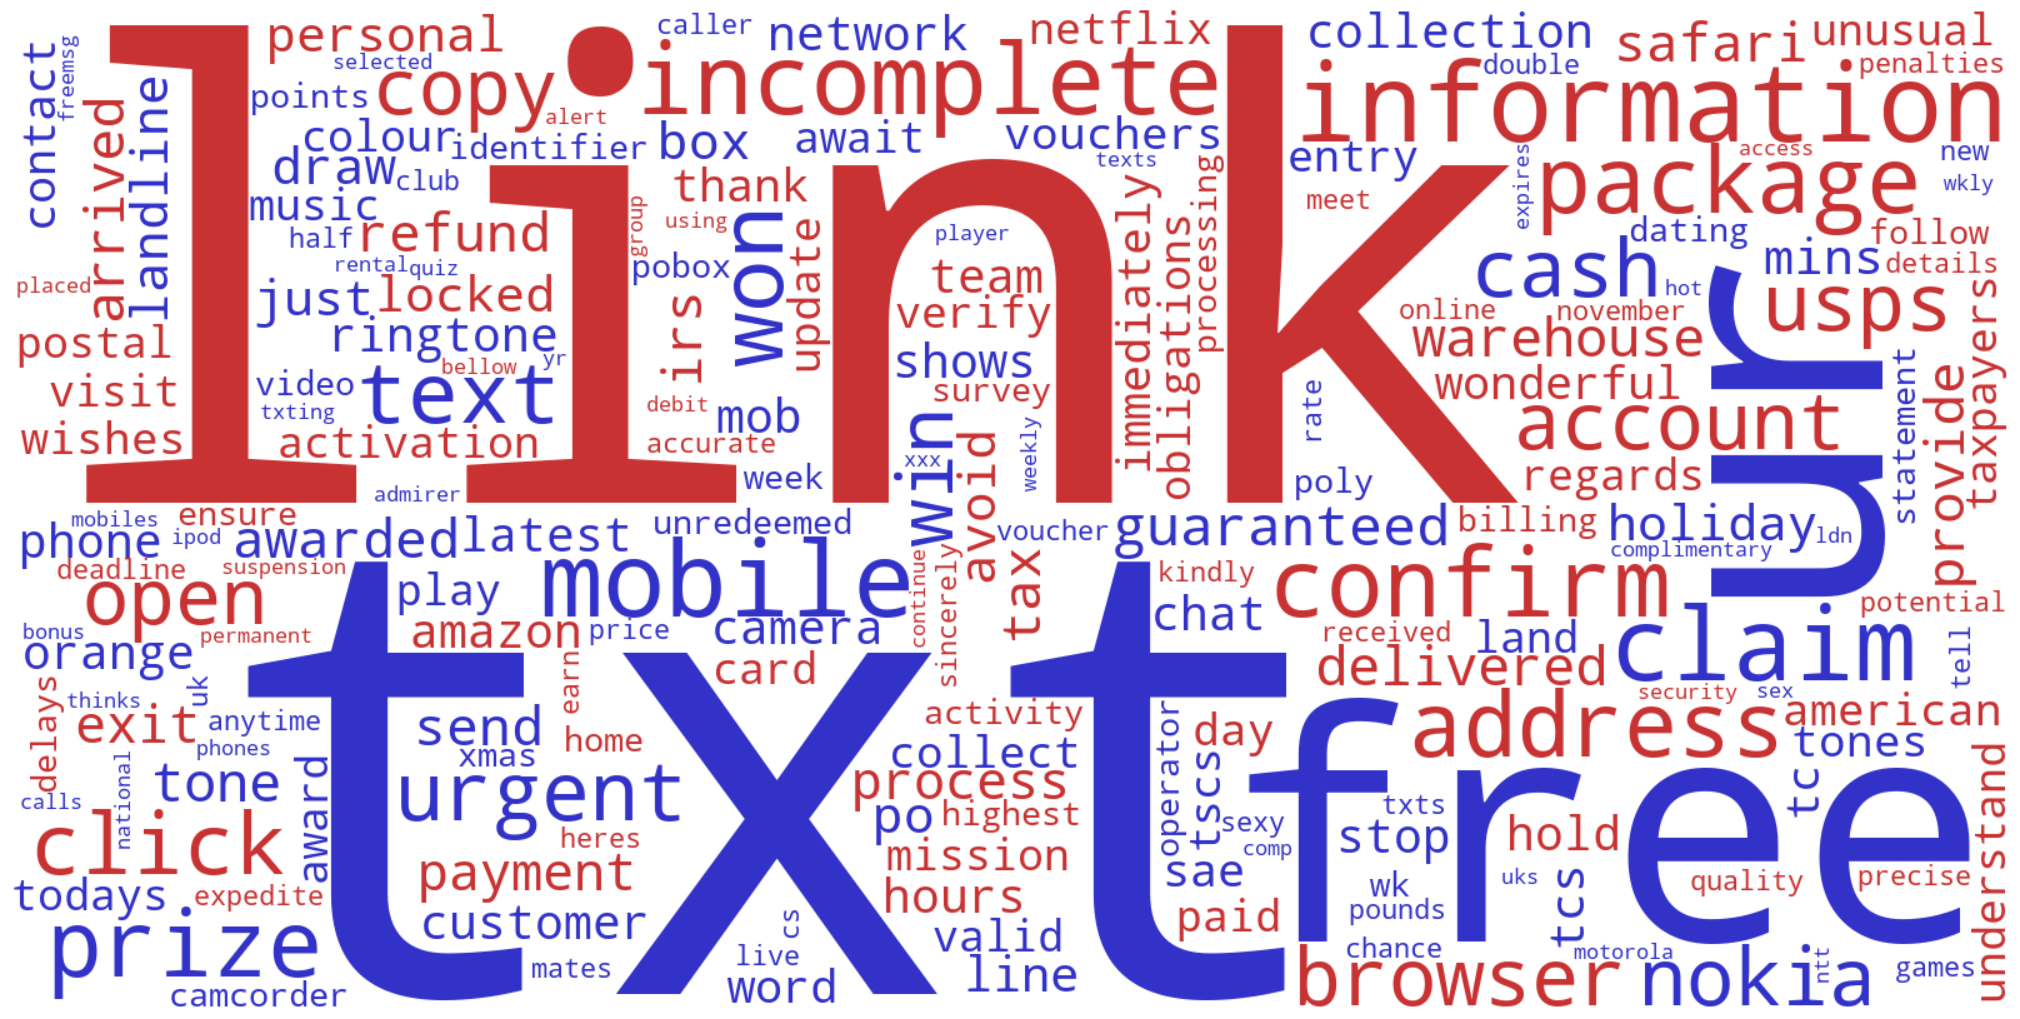

In [128]:
df_results = get_chi2_drift_scores(deep_clean(texts_2011), deep_clean(texts_2024))
generate_drift_wordcloud(df_results)

In [134]:
def generate_smishing_wordcloud(texts, title="Smishing Vocabulary Analysis"):
    # 1. Clean and join the text from the single dataset
    clean_text = " ".join([str(t) for t in texts if pd.notnull(t)])

    wc_settings = {
        "width": 1600,
        "height": 800,
        "background_color": "#0F0F0F", # Very dark grey/black
        "max_words": 100,
        "colormap": "cool",            # Professional cyan/purple/blue tones
        "collocations": False,
        "contour_width": 1,
        "contour_color": 'steelblue'
    }

    # 3. Generate the cloud
    wc = WordCloud(**wc_settings).generate(clean_text)

    # 4. FIX: Manual conversion to NumPy array 
    # This bypasses the 'asarray() got an unexpected keyword argument copy' error
    img_array = np.array(wc.to_image())

    # 5. Plotting
    plt.figure(figsize=(15, 7.5))
    plt.imshow(img_array, interpolation='bilinear')
    
    plt.title(title, fontsize=25, pad=20, fontweight='bold')
    plt.axis("off")
    plt.tight_layout(pad=0)
    
    # plt.savefig("smishing_cloud.png", dpi=300)
    plt.show()

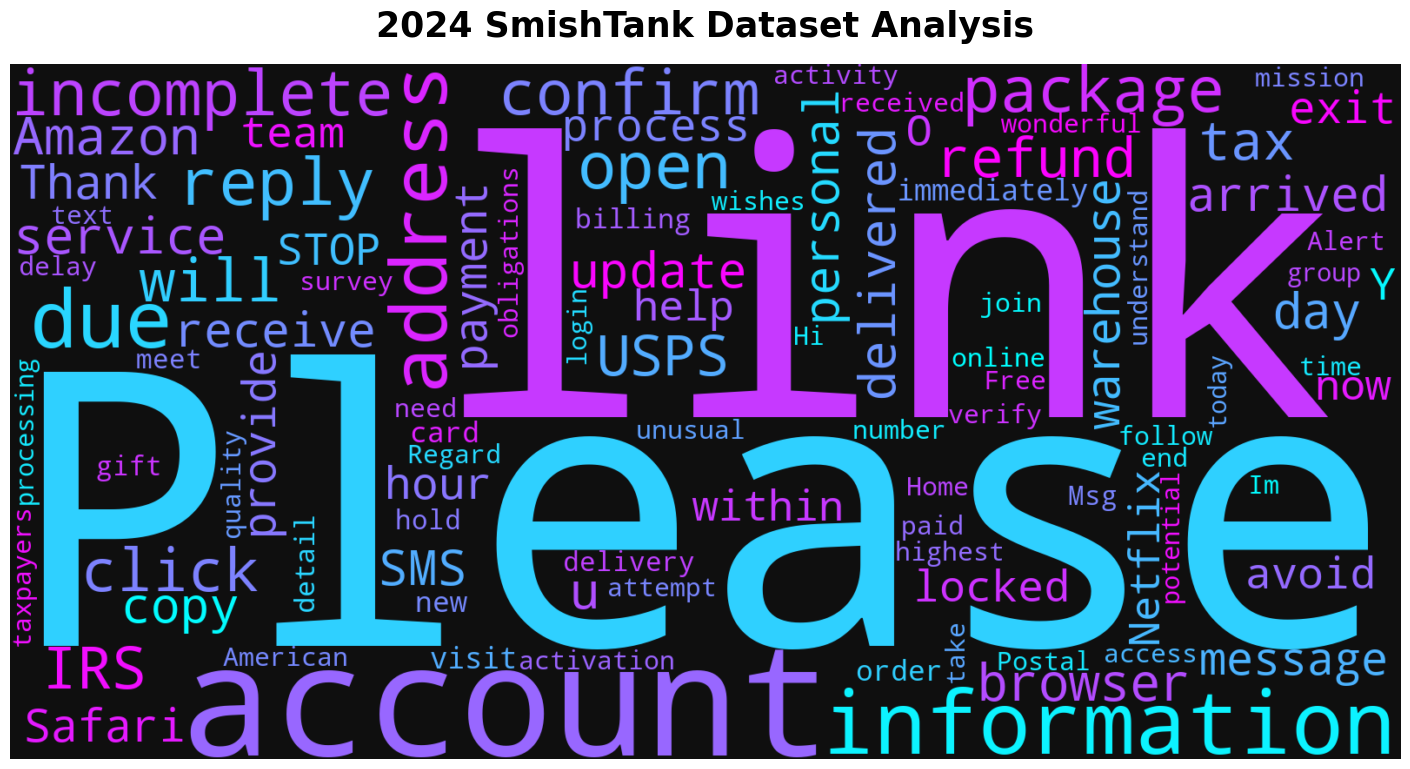

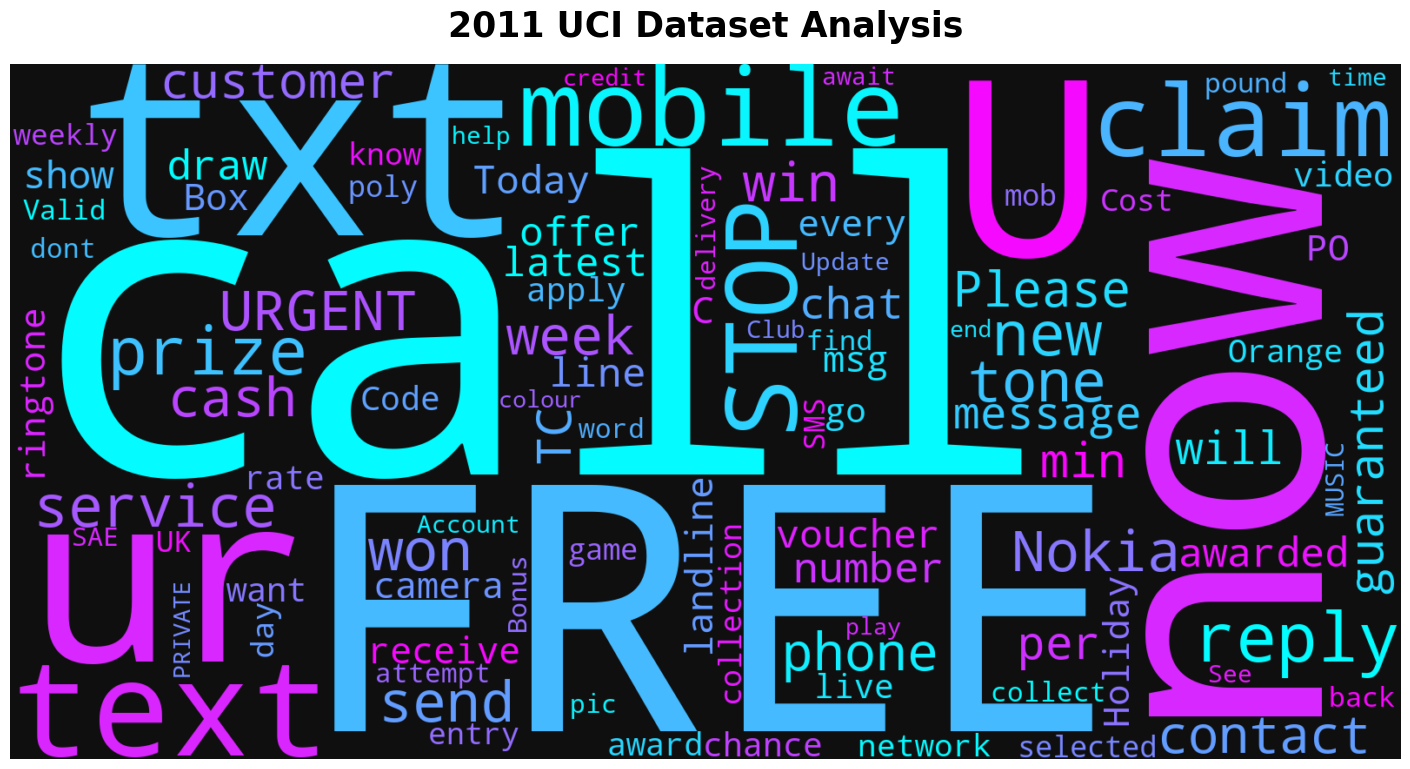

In [135]:
# To use for your 2024 dataset:
generate_smishing_wordcloud(texts_2024, title="2024 SmishTank Dataset Analysis")

# To use for your 2011 dataset:
generate_smishing_wordcloud(texts_2011, title="2011 UCI Dataset Analysis")

In [137]:
# Phone number count analysis

UCI_spam_phone = pd.read_csv('../Phone Data/UCI Dataset Spam.csv')
uci_phone_spam = 100*len(UCI_spam_phone)/len(UCI_dataset_spam)
print(100*len(UCI_spam_phone)/len(UCI_dataset_spam))

smishtank_phone = pd.read_csv('../Phone Data/SmishTank Dataset.csv')
smishtank_phone_spam = 100*len(smishtank_phone)/len(smishtank_dataset)
print(100*len(smishtank_phone)/len(smishtank_dataset))

44.57831325301205
3.483043079743355


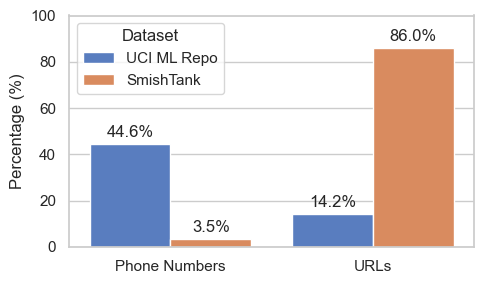

In [138]:

data = {
    'Dataset': ['UCI ML Repo', 'UCI ML Repo', 'SmishTank', 'SmishTank'],
    'Category': ['Phone Numbers', 'URLs', 'Phone Numbers', 'URLs'],
    'Percentage': [uci_phone_spam, 14.19, smishtank_phone_spam, 85.98]  
}

df = pd.DataFrame(data)

plt.figure(figsize=(5, 3))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df, 
    x='Category', 
    y='Percentage', 
    hue='Dataset', 
    palette='muted'
)


plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylim(0, 100)  


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

In [139]:
# Entropy Analysis

def calculate_shannon_entropy(text):
    """
    Calculates the Shannon Entropy of a string.
    Higher values = more randomness/obfuscation.
    """
    if not text or not isinstance(text, str):
        return 0
    
    # Calculate probability of each character
    prob = [float(text.count(c)) / len(text) for c in dict.fromkeys(list(text))]
    
    # Calculate entropy
    entropy = - sum([p * math.log(p) / math.log(2.0) for p in prob])
    return entropy

def analyze_entropy_drift(texts_2011, texts_2024):
    # 1. Calculate entropy for both groups
    entropy_11 = [calculate_shannon_entropy(str(t)) for t in texts_2011]
    entropy_24 = [calculate_shannon_entropy(str(t)) for t in texts_2024]
    
    avg_11 = np.mean(entropy_11)
    avg_24 = np.mean(entropy_24)
    
    # 2. Statistical Test (T-test) to prove the difference is significant
    t_stat, p_val = ttest_ind(entropy_24, entropy_11)
    
    print(f"Results of Entropy Analysis:")
    print(f"-"*30)
    print(f"Average Entropy 2011 (UCI): {avg_11:.4f}")
    print(f"Average Entropy 2024 (SmishTank): {avg_24:.4f}")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4e}")
    
    # 3. Visualization for the Paper
    plt.figure(figsize=(10, 6))
    sns.kdeplot(entropy_11, label="2011 (Legacy SMS)", fill=True, color="blue")
    sns.kdeplot(entropy_24, label="2024 (Modern Smishing)", fill=True, color="red")
    plt.title("Distribution of Shannon Entropy: 2011 vs. 2024", fontsize=14)
    plt.xlabel("Shannon Entropy Score", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend()
    plt.savefig("entropy_drift_analysis.png", dpi=300)
    plt.show()

In [147]:
# taking original messages
texts_2011 = [UCI_dataset_spam[i] for i in range(len(UCI_dataset_spam))]

texts_2024 = [str(t) for t in smishtank_dataset['MainText'] if pd.notnull(t) and str(t).strip() != ""]

Results of Entropy Analysis:
------------------------------
Average Entropy 2011 (UCI): 4.6976
Average Entropy 2024 (SmishTank): 4.6414
T-statistic: -4.4204, P-value: 1.0437e-05


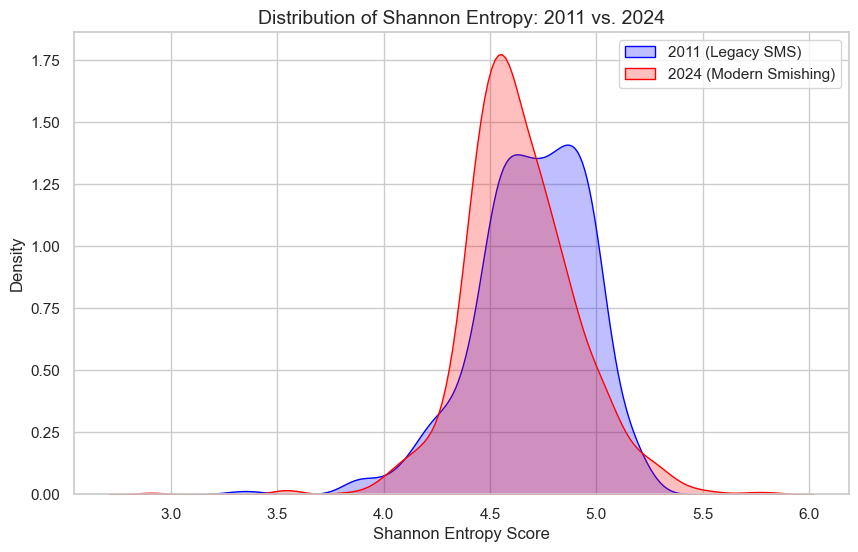

In [148]:
analyze_entropy_drift(texts_2011, texts_2024)

In [143]:
def calculate_special_char_density(text):
    """
    Calculates the ratio of punctuation/special characters to total length.
    """
    if not text or not isinstance(text, str) or len(text) == 0:
        return 0
    
    # Define what we consider 'special' (punctuation + symbols)
    # string.punctuation includes !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    special_chars = [char for char in text if char in string.punctuation]
    
    return len(special_chars) / len(text)

def analyze_punctuation_drift(texts_2011, texts_2024):
    # 1. Calculate densities
    density_11 = [calculate_special_char_density(str(t)) for t in texts_2011]
    density_24 = [calculate_special_char_density(str(t)) for t in texts_2024]
    
    avg_11 = np.mean(density_11)
    avg_24 = np.mean(density_24)
    
    # 2. Statistical Significance
    t_stat, p_val = ttest_ind(density_24, density_11)
    
    print(f"Punctuation Density Analysis:")
    print(f"-"*30)
    print(f"Avg Density 2011 (UCI): {avg_11:.4f} ({avg_11*100:.2f}%)")
    print(f"Avg Density 2024 (SmishTank): {avg_24:.4f} ({avg_24*100:.2f}%)")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4e}")
    
    # 3. Visualization
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=[density_11, density_24], palette="Set2")
    plt.xticks([0, 1], ['2011 (UCI)', '2024 (SmishTank)'])
    plt.title("Comparison of Special Character Density", fontsize=14)
    plt.ylabel("Density Ratio (Special Chars / Total Chars)")
    plt.savefig("punctuation_drift.png", dpi=300)
    plt.show()

Punctuation Density Analysis:
------------------------------
Avg Density 2011 (UCI): 0.0410 (4.10%)
Avg Density 2024 (SmishTank): 0.0676 (6.76%)
T-statistic: 17.9822, P-value: 1.2345e-66


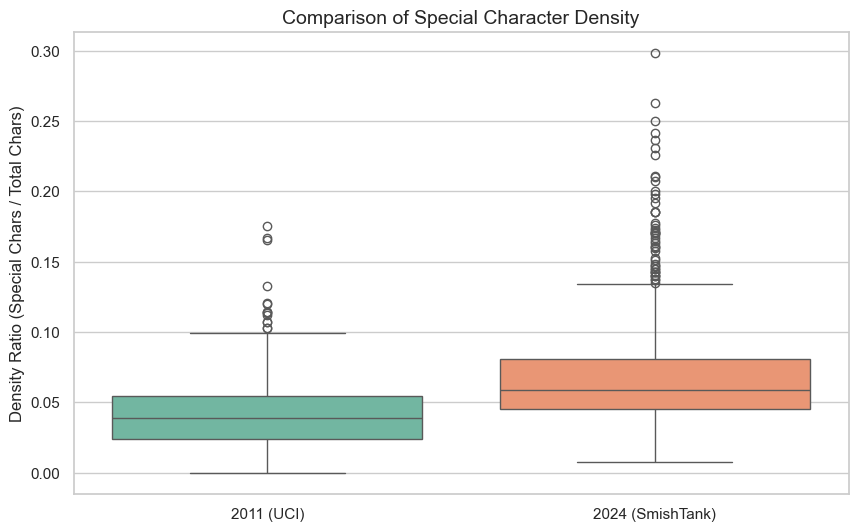

In [149]:
analyze_punctuation_drift(texts_2011, texts_2024)